## STUDENT INFO: 
### Name                      |   Matric No
### i.NG YU HIN                   A23CS0148
### ii.SABRINA HENG WEI QI        A23CS0265
### iii.CHAU YING JIA             A23CS0213
### 
### Section:02

# Rainfall Data Analysis Assignment (100 Marks, Due 6th July 2025)

You are provided with a rainfall dataset recording monthly measurements from various weather stations across different regions. The dataset includes rainfall (mm), number of rainy days, maximum and minimum temperatures, and whether the station is in an urban or rural area.

Dataset columns:

- `Region`: Name of the region (e.g., North, South, East, West)
- `Year`: Year of measurement
- `Month`: Month (e.g., Jan, Feb, ..., Dec)
- `Station`: Weather station name/ID (e.g., StationA, StationB)
- `Rainfall_mm`: Rainfall amount in millimeters
- `RainyDays`: Number of days in the month with rain
- `MaxTemp_C`: Maximum temperature recorded in that month (°C)
- `MinTemp_C`: Minimum temperature recorded in that month (°C)
- `UrbanRural`: "Urban" or "Rural"

## Part 1: Data Exploration ( 15 Marks)

1. Load the data into a pandas DataFrame. (2 Marks)
2. Display the first 5 rows of the DataFrame. (2 Marks)
3. Check for and handle any missing values. (6 Marks)
4. Provide summary statistics for all numeric columns. (5 Marks)

In [99]:
#Write your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#1. Load the data into a pandas DataFrame
rain_df = pd.read_csv('Rainfall.csv')
if rain_df.shape[1] == 1 and isinstance(rain_df.columns[0],str) and ',' in rain_df.columns[0]:
    print("Warning: CSV loaded as a single column.Atempting to split manually.")
    # Get the header string from single column's name
    header_str = rain_df.columns[0]
    # Split the header string to get column names
    column_names = header_str.split(',')

    # Apply a split function to the single column's values and create new columns
    # Then assign the correct column names
    data = rain_df[header_str].apply(lambda x: pd.Series(x.split(',')))
    data.columns = column_names
    rain_df = data # Overwrite the single-column DataFrame with the new one

    # After splitting, attempt to convert relevant columns to numeric type
    # Use 'coerce' to turn unconvertible values into NaN, which will be handled later.
    for col in ['Year', 'Rainfall_mm', 'RainyDays', 'MaxTemp_C', 'MinTemp_C']:
        if col in rain_df.columns: # Check if column exists after splitting
            rain_df[col] = pd.to_numeric(rain_df[col], errors='coerce')

rain_df = rain_df.reset_index(drop = True)
rain_df.index = range(1,len(rain_df)+1)
rain_df

,Region,Year,Month,Station,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C,UrbanRural
1,North,2023,Jan,StationA,56.2,9,12.1,2.5,Urban
2,North,2023,Feb,StationA,72.1,12,14.7,3.0,Urban
3,North,2023,Jan,StationB,60.5,10,11.2,1.8,Rural
4,South,2023,Jan,StationC,81.0,13,19.6,7.2,Urban
5,South,2023,Feb,StationC,63.4,11,20.1,7.7,Urban
6,East,2023,Jan,StationD,45.7,8,15.4,5.6,Rural
7,East,2023,Feb,StationD,59.6,10,17.9,6.2,Rural
8,West,2023,Jan,StationE,77.4,12,16.8,4.9,Urban
9,West,2023,Feb,StationE,84.2,13,18.2,5.3,Urban
10,North,2023,Mar,StationB,61.5,11,15.0,3.2,Rural


In [101]:
rain_df.dtypes

Region          object
Year             int64
Month           object
Station         object
Rainfall_mm    float64
RainyDays        int64
MaxTemp_C      float64
MinTemp_C      float64
UrbanRural      object
dtype: object

In [103]:
# After splitting, attempt to convert relevant columns to numeric type
# Use 'coerce' to turn unconvertible values into NaN, which will be handled later.
for col in ['Year', 'Rainfall_mm', 'RainyDays', 'MaxTemp_C', 'MinTemp_C']:
    if col in rain_df.columns: # Check if column exists after splitting
        rain_df[col] = pd.to_numeric(rain_df[col], errors='coerce')

rain_df

,Region,Year,Month,Station,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C,UrbanRural
1,North,2023,Jan,StationA,56.2,9,12.1,2.5,Urban
2,North,2023,Feb,StationA,72.1,12,14.7,3.0,Urban
3,North,2023,Jan,StationB,60.5,10,11.2,1.8,Rural
4,South,2023,Jan,StationC,81.0,13,19.6,7.2,Urban
5,South,2023,Feb,StationC,63.4,11,20.1,7.7,Urban
6,East,2023,Jan,StationD,45.7,8,15.4,5.6,Rural
7,East,2023,Feb,StationD,59.6,10,17.9,6.2,Rural
8,West,2023,Jan,StationE,77.4,12,16.8,4.9,Urban
9,West,2023,Feb,StationE,84.2,13,18.2,5.3,Urban
10,North,2023,Mar,StationB,61.5,11,15.0,3.2,Rural


In [105]:
rain_df.describe()

,Year,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C
count,10.0,10.000000,10.00000,10.000000,10.000000
mean,2023.0,66.160000,10.90000,16.100000,4.740000
std,0.0,12.154121,1.66333,2.982542,2.029888
min,2023.0,45.700000,8.00000,11.200000,1.800000
25%,2023.0,59.825000,10.00000,14.775000,3.050000
50%,2023.0,62.450000,11.00000,16.100000,5.100000
75%,2023.0,76.075000,12.00000,18.125000,6.050000
max,2023.0,84.200000,13.00000,20.100000,7.700000


In [107]:
#2. Display the first 5 rows of the DataFrame
rain_df.head()

,Region,Year,Month,Station,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C,UrbanRural
1,North,2023,Jan,StationA,56.2,9,12.1,2.5,Urban
2,North,2023,Feb,StationA,72.1,12,14.7,3.0,Urban
3,North,2023,Jan,StationB,60.5,10,11.2,1.8,Rural
4,South,2023,Jan,StationC,81.0,13,19.6,7.2,Urban
5,South,2023,Feb,StationC,63.4,11,20.1,7.7,Urban


In [109]:
# 3.Check for and handle any missing values
print("Missing values before handling:")
print(rain_df.isnull().sum())

# Handle missing numerical values by filling with the mean
for col in rain_df.select_dtypes(include=['number']).columns:
    if rain_df[col].isnull().any():
        rain_df[col].fillna(rain_df[col].mean(), inplace=True)

# Handle missing categorical values by filling with the mode
for col in rain_df.select_dtypes(include=['object']).columns:
    if rain_df[col].isnull().any():
        rain_df[col].fillna(rain_df[col].mode()[0], inplace=True)

print("\nMissing values after handling:")
print(rain_df.isnull().sum())

Missing values before handling:
Region         0
Year           0
Month          0
Station        0
Rainfall_mm    0
RainyDays      0
MaxTemp_C      0
MinTemp_C      0
UrbanRural     0
dtype: int64

Missing values after handling:
Region         0
Year           0
Month          0
Station        0
Rainfall_mm    0
RainyDays      0
MaxTemp_C      0
MinTemp_C      0
UrbanRural     0
dtype: int64


In [111]:
# 4.Provide summary statistics for all numeric columns
rain_df.describe()

,Year,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C
count,10.0,10.000000,10.00000,10.000000,10.000000
mean,2023.0,66.160000,10.90000,16.100000,4.740000
std,0.0,12.154121,1.66333,2.982542,2.029888
min,2023.0,45.700000,8.00000,11.200000,1.800000
25%,2023.0,59.825000,10.00000,14.775000,3.050000
50%,2023.0,62.450000,11.00000,16.100000,5.100000
75%,2023.0,76.075000,12.00000,18.125000,6.050000
max,2023.0,84.200000,13.00000,20.100000,7.700000


In [113]:
rain_df

,Region,Year,Month,Station,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C,UrbanRural
1,North,2023,Jan,StationA,56.2,9,12.1,2.5,Urban
2,North,2023,Feb,StationA,72.1,12,14.7,3.0,Urban
3,North,2023,Jan,StationB,60.5,10,11.2,1.8,Rural
4,South,2023,Jan,StationC,81.0,13,19.6,7.2,Urban
5,South,2023,Feb,StationC,63.4,11,20.1,7.7,Urban
6,East,2023,Jan,StationD,45.7,8,15.4,5.6,Rural
7,East,2023,Feb,StationD,59.6,10,17.9,6.2,Rural
8,West,2023,Jan,StationE,77.4,12,16.8,4.9,Urban
9,West,2023,Feb,StationE,84.2,13,18.2,5.3,Urban
10,North,2023,Mar,StationB,61.5,11,15.0,3.2,Rural


## Part 2: Grouping and Aggregation (30 Marks)

1. For each **Station**, compute: (6 Marks)
    - Total rainfall 
    - Average number of rainy days 
    - Average maximum temperature 
    - Average minimum temperature



In [116]:
#Write your code here
station = rain_df.groupby(['Station']).agg(
    Total_Rainfall = ('Rainfall_mm','sum'),
    Avg_RainyDays = ('RainyDays','mean'),
    Avg_MaxTemp_C = ('MaxTemp_C','mean'),
    Avg_MinTemp_C = ('MinTemp_C','mean')
)

station

,Total_Rainfall,Avg_RainyDays,Avg_MaxTemp_C,Avg_MinTemp_C
Station,,,,
StationA,128.3,10.5,13.40,2.75
StationB,122.0,10.5,13.10,2.50
StationC,144.4,12.0,19.85,7.45
StationD,105.3,9.0,16.65,5.90
StationE,161.6,12.5,17.50,5.10


2. For each **Region & UrbanRural** combination, calculate: (6 Marks)
    - Average rainfall
    - Average maximum temperature
    - Average number of rainy days


In [119]:
#Write your code here
reg_urb_rural =rain_df.groupby(['Region','UrbanRural']).agg(
    Avg_Rainfall=('Rainfall_mm','mean'),
    Avg_MaxTemp_C = ('MaxTemp_C','mean'),
    Avg_RainyDays = ('RainyDays','mean'),
)

reg_urb_rural

Avg_Rainfall  Avg_MaxTemp_C  Avg_RainyDays
Region UrbanRural                                            
East   Rural              52.65          16.65            9.0
North  Rural              61.00          13.10           10.5
       Urban              64.15          13.40           10.5
South  Urban              72.20          19.85           12.0
West   Urban              80.80          17.50           12.5

3. For each **Month** and **Region**, calculate: (6 Marks)
    - Total rainfall
    - Mean rainfall
    - Minimum and maximum rainfall


In [122]:
#Write your code here
month_reg = rain_df.groupby(['Month','Region']).agg(
    Total_Rainfall = ('Rainfall_mm','sum'),
    Avg_Rainfall = ('Rainfall_mm','mean'),
    Min_Rainfall = ('Rainfall_mm','min'),
    Max_Rainfall = ('Rainfall_mm','max')
)

month_reg

Total_Rainfall  Avg_Rainfall  Min_Rainfall  Max_Rainfall
Month Region                                                          
Feb   East              59.6         59.60          59.6          59.6
      North             72.1         72.10          72.1          72.1
      South             63.4         63.40          63.4          63.4
      West              84.2         84.20          84.2          84.2
Jan   East              45.7         45.70          45.7          45.7
      North            116.7         58.35          56.2          60.5
      South             81.0         81.00          81.0          81.0
      West              77.4         77.40          77.4          77.4
Mar   North             61.5         61.50          61.5          61.5

4. Find the **Region and Month** with the highest recorded rainfall in the dataset. (4 Marks)


In [125]:
#Write your code here
highest_rainfall_entry = rain_df.loc[rain_df['Rainfall_mm'].idxmax()]
print("\n4. Region and Month with the highest recorded rainfall:")
print(f"Region: {highest_rainfall_entry['Region']}, Month: {highest_rainfall_entry['Month']}, Rainfall: {highest_rainfall_entry['Rainfall_mm']} mm")


4. Region and Month with the highest recorded rainfall:
Region: West, Month: Feb, Rainfall: 84.2 mm


5. For each **Year** and **UrbanRural** group, calculate: (4 Marks)
    - Average rainfall
    - Minimum rainfall
    - Maximum rainfall



In [128]:
#Write your code here
yr_urb_rural = rain_df.groupby(['Year','UrbanRural']).agg(
    Avg_Rainfall = ('Rainfall_mm','mean'),
    Min_Rainfall = ('Rainfall_mm','min'),
    Max_Rainfall = ('Rainfall_mm','max')
)

yr_urb_rural

Avg_Rainfall  Min_Rainfall  Max_Rainfall
Year UrbanRural                                          
2023 Rural          56.825000          45.7          61.5
     Urban          72.383333          56.2          84.2

6. For each **Region**, calculate the average temperature range per month (i.e., average of MaxTemp_C - MinTemp_C). (4 Marks)

In [131]:
#Write your code here
rain_df['Temp_Range'] = rain_df['MaxTemp_C'] - rain_df['MinTemp_C']
avg_temp_range_by_region = rain_df.groupby('Region').agg(
    Avg_Temp_Range_per_Month = ('Temp_Range','mean')
)
avg_temp_range_by_region

,Avg_Temp_Range_per_Month
Region,
East,10.750
North,10.625
South,12.400
West,12.400


## Part 3: Data Visualization (matplotlib) (40 Marks)

1. **Bar Chart:**  (8 Marks)
   - Plot total rainfall by region, colored by Urban/Rural.
   - Add value labels, gridlines, axis labels, title, and adjust bar width for clarity.



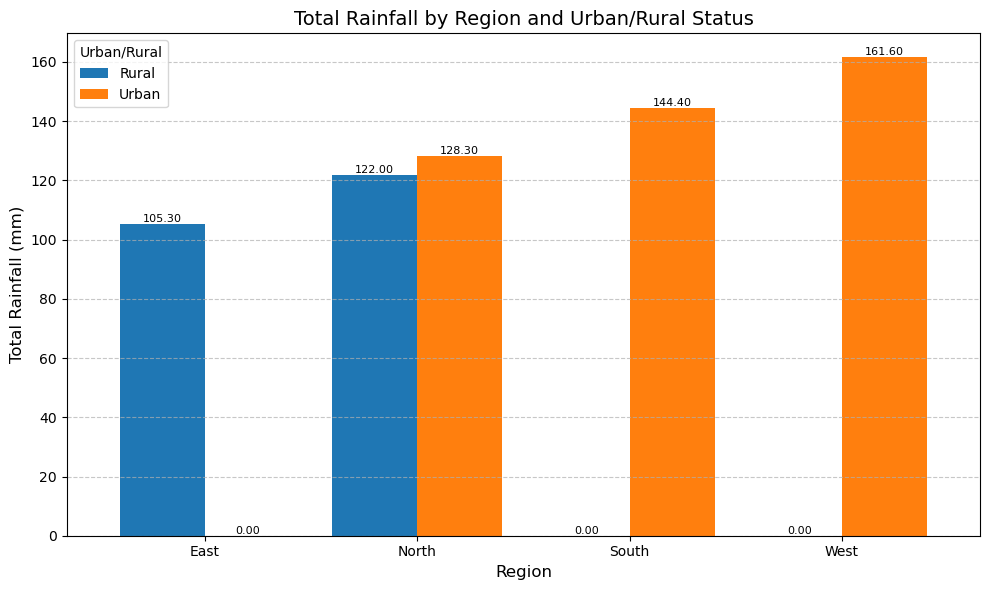

In [134]:
#Write your code here
total_rainfall_by_region_urbanrural = rain_df.groupby(['Region','UrbanRural'])['Rainfall_mm'].sum().unstack()
fig1,ax1 = plt.subplots(figsize=(10,6))
total_rainfall_by_region_urbanrural.plot(kind='bar', ax=ax1,width=0.8)

ax1.set_title('Total Rainfall by Region and Urban/Rural Status', fontsize=14)
ax1.set_xlabel('Region',fontsize = 12)
ax1.set_ylabel('Total Rainfall (mm)',fontsize=12)
ax1.grid(axis='y',linestyle='--',alpha=0.7)
ax1.tick_params(axis='x',rotation=0)
ax1.legend(title='Urban/Rural')

for container in  ax1.containers:
    ax1.bar_label(container,fmt='%.2f',label_type='edge',fontsize = 8)

plt.tight_layout()
plt.savefig('total_rainfall_by_region_urbanrural_bar_chart.png')
plt.show()

2. **Grouped Bar Chart:**  (6 Marks)
   - Show average monthly rainfall for each station.
   - Use different colors for each station, include a legend, rotate x-tick labels, and increase figure size for readability.



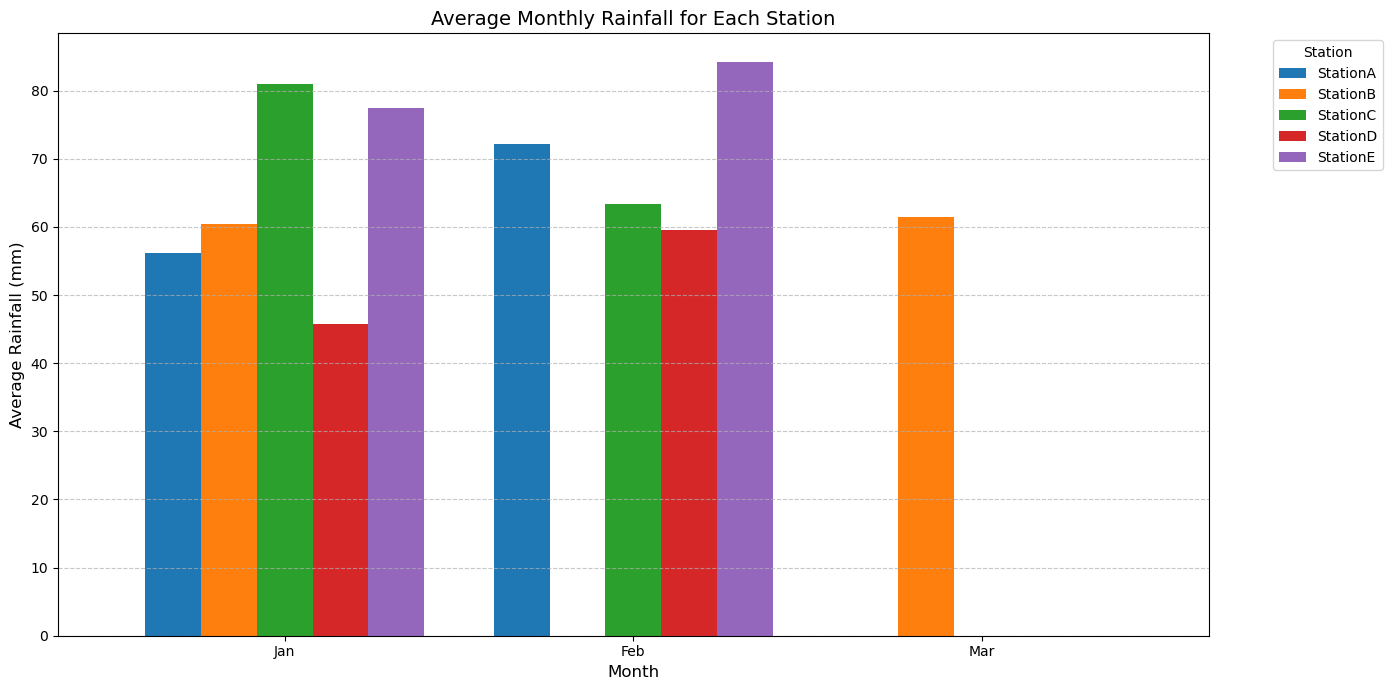

In [137]:
#Write your code here
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
#Group and pivot
avg_monthly_rainfall_station = rain_df.groupby(['Month','Station'])['Rainfall_mm'].mean().unstack()

#Filter only months present in the data
present_months = [m for m in months if m in avg_monthly_rainfall_station.index]
avg_monthly_rainfall_station = avg_monthly_rainfall_station.reindex(present_months)

fig2, ax2 = plt.subplots(figsize=(14,7))
avg_monthly_rainfall_station.plot(kind='bar',ax=ax2,width=0.8)

ax2.set_title('Average Monthly Rainfall for Each Station',fontsize=14)
ax2.set_xlabel('Month',fontsize=12)
ax2.set_ylabel('Average Rainfall (mm)',fontsize=12)
ax2.grid(axis='y',linestyle='--',alpha=0.7)
ax2.tick_params(axis='x',rotation=0)
ax2.legend(title='Station', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('avg_monthly_rainfall_grouped_bar_chart.png')
plt.show()

3. **Line Plot:**  (6 Marks)
   - Show the trend of rainfall over months for at least two selected stations.
   - Use markers, dashed lines, highlight the month with maximum rainfall, and format the x-axis for months.



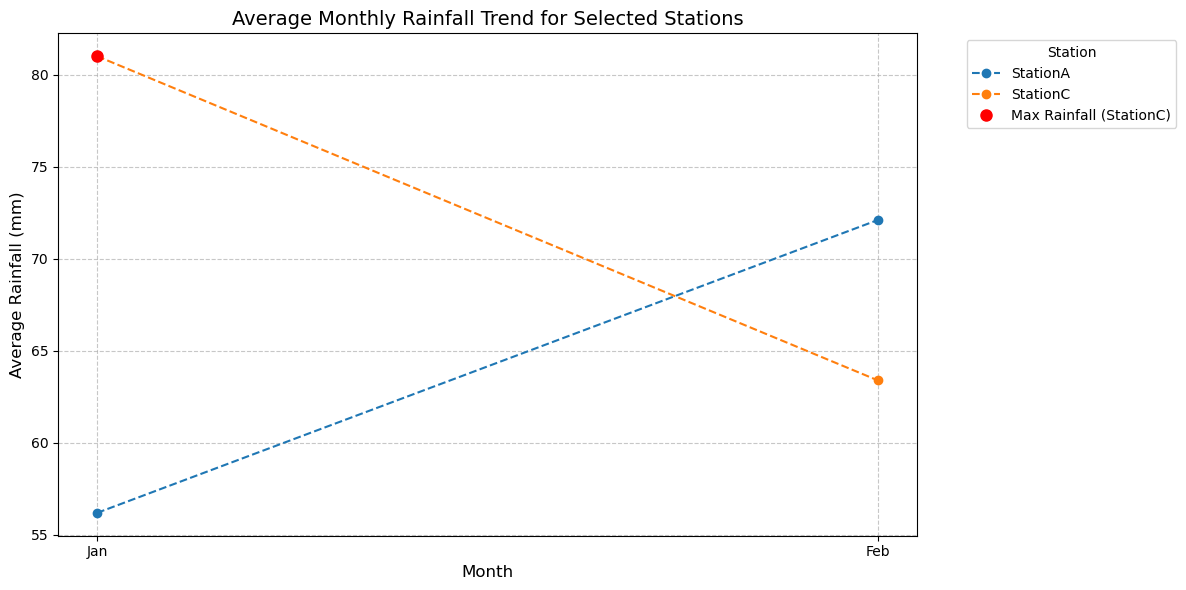

In [140]:
#Write your code here
selected_stations = ['StationA', 'StationC']
rainfall_trend = rain_df[rain_df['Station'].isin(selected_stations)].groupby(['Month', 'Station'])['Rainfall_mm'].mean().unstack()

# Reorder months
rainfall_trend = rainfall_trend.reindex(present_months)

fig3, ax3 = plt.subplots(figsize=(12, 6))
for station in selected_stations:
    if station in rainfall_trend.columns:
        ax3.plot(rainfall_trend.index, rainfall_trend[station], label=station, marker='o', linestyle='--')

# Highlight month with maximum rainfall for this station
max_rainfall_month = rainfall_trend[station].idxmax()
max_rainfall_value = rainfall_trend[station].max()
ax3.plot(max_rainfall_month, max_rainfall_value, 'ro', markersize=8, label=f'Max Rainfall ({station})')

ax3.set_title('Average Monthly Rainfall Trend for Selected Stations', fontsize=14)
ax3.set_xlabel('Month', fontsize=12)
ax3.set_ylabel('Average Rainfall (mm)', fontsize=12)
ax3.grid(True, linestyle='--', alpha=0.7)
ax3.legend(title='Station',bbox_to_anchor=(1.05,1), loc='upper left')
ax3.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('rainfall_trend_line_plot.png')
plt.show()

4. **Boxplot:**  (6 Marks)
   - Display rainfall distributions by region and by Urban/Rural.
   - Use custom box colors, highlight outliers, and set y-axis limits.



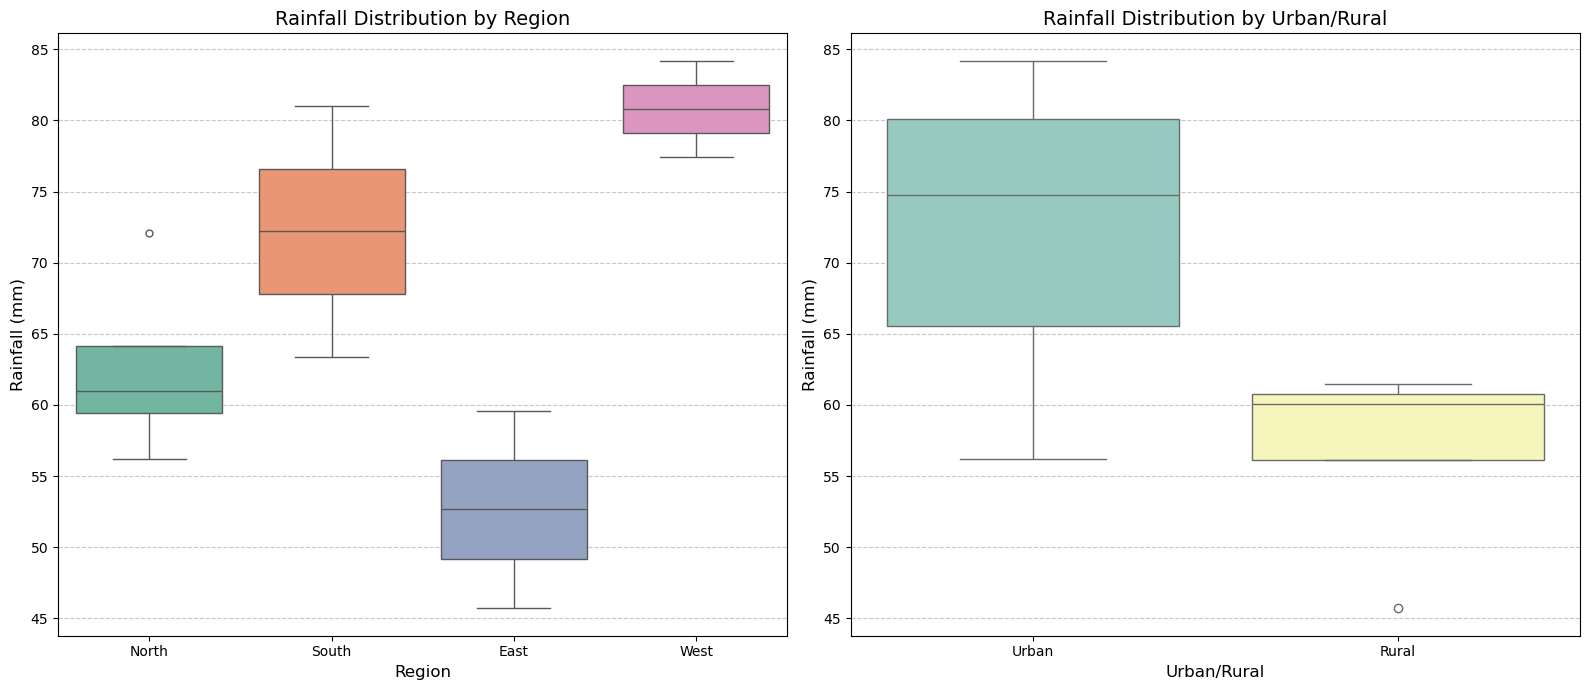

In [143]:
#Write your code here
fig4, axes4 = plt.subplots(1, 2, figsize=(16, 7))

# --- Boxplot by Region ---
sns.boxplot(x='Region', y='Rainfall_mm',hue='Region',data=rain_df, ax=axes4[0], palette='Set2', fliersize=5)
axes4[0].set_title('Rainfall Distribution by Region', fontsize=14)
axes4[0].set_xlabel('Region', fontsize=12)
axes4[0].set_ylabel('Rainfall (mm)', fontsize=12)
axes4[0].tick_params(axis='x', rotation=0)
axes4[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Boxplot by Urban/Rural ---
sns.boxplot(x='UrbanRural', y='Rainfall_mm',hue='UrbanRural', data=rain_df, ax=axes4[1], palette='Set3', fliersize=6)
axes4[1].set_title('Rainfall Distribution by Urban/Rural', fontsize=14)
axes4[1].set_xlabel('Urban/Rural', fontsize=12)
axes4[1].set_ylabel('Rainfall (mm)', fontsize=12)
axes4[1].tick_params(axis='x', rotation=0)
axes4[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('rainfall_distribution_boxplots_customized.png')
plt.show()

5. **Scatter Plot:**  (6 Marks)
   - Visualize the relationship between rainfall and maximum temperature, colored by region.
   - Add axis labels, legend, gridlines, and an appropriate title.



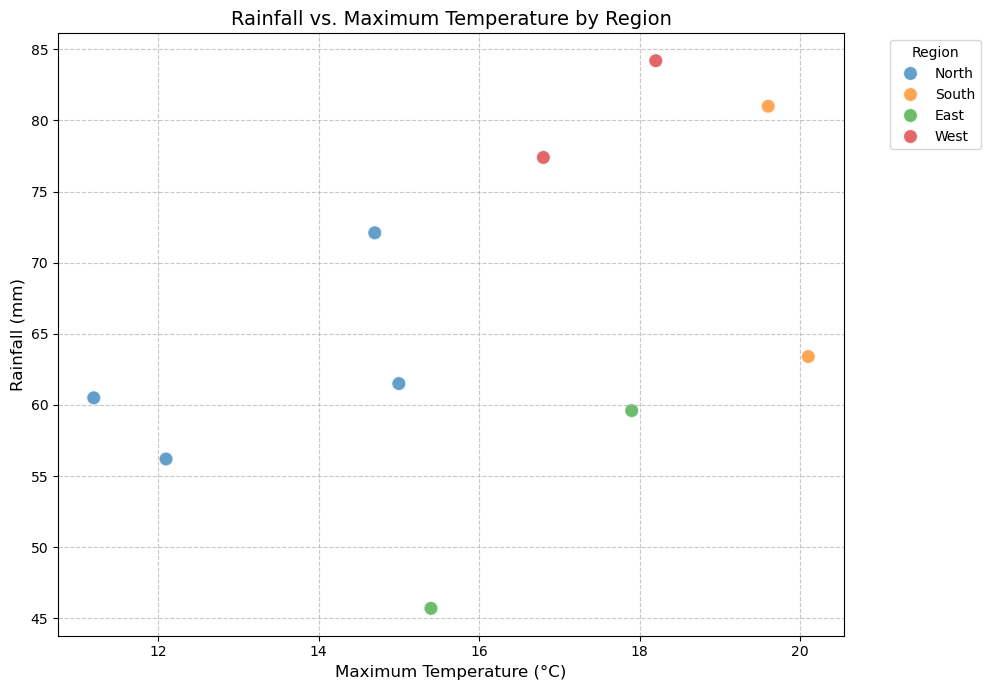

In [146]:
#Write your code here
fig5, ax5 = plt.subplots(figsize=(10, 7))
sns.scatterplot(x='MaxTemp_C', y='Rainfall_mm', hue='Region', data=rain_df, ax=ax5, s=100, alpha=0.7)

ax5.set_title('Rainfall vs. Maximum Temperature by Region', fontsize=14)
ax5.set_xlabel('Maximum Temperature (°C)', fontsize=12)
ax5.set_ylabel('Rainfall (mm)', fontsize=12)
ax5.grid(True, linestyle='--', alpha=0.7)
ax5.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('rainfall_vs_maxtemp_scatter_plot.png')
plt.show()

6. **Heatmap:**  
   - Create a heatmap showing mean monthly rainfall for each region (Month on x-axis, Region on y-axis).
   - Add color bar, axis labels, and title.



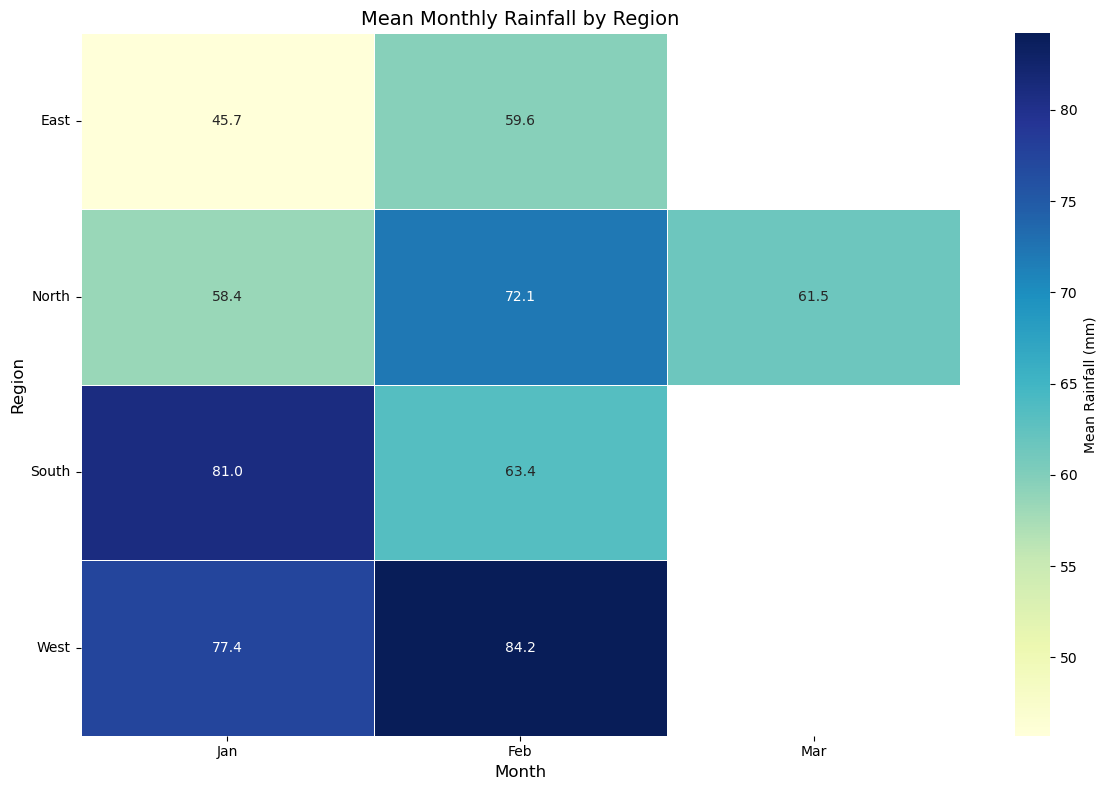

In [149]:
#Write your code here
mean_rainfall_heatmap_data = rain_df.pivot_table(index='Region', columns='Month', values='Rainfall_mm', aggfunc='mean')

# Reorder columns (months) for chronological order
mean_rainfall_heatmap_data = mean_rainfall_heatmap_data.reindex(columns=present_months)

fig6, ax6 = plt.subplots(figsize=(12, 8))
sns.heatmap(mean_rainfall_heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5, ax=ax6, cbar_kws={'label': 'Mean Rainfall (mm)'})

ax6.set_title('Mean Monthly Rainfall by Region', fontsize=14)
ax6.set_xlabel('Month', fontsize=12)
ax6.set_ylabel('Region', fontsize=12)
ax6.tick_params(axis='x', rotation=0)
ax6.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('mean_monthly_rainfall_heatmap.png')
plt.show()

7. **Formatting (for all plots):** (8 Marks)
   - Use descriptive titles, axis labels, and legends.
   - Increase font size for readability.
   - Save each figure as an image file (`.png`).
   - Use `plt.tight_layout()` for proper spacing.

In [162]:
#Write your code here

## Part 4: Bonus Tasks (15 Marks)

1. Annotate at least one plot with the value and label of the highest/lowest point. (5 Marks)


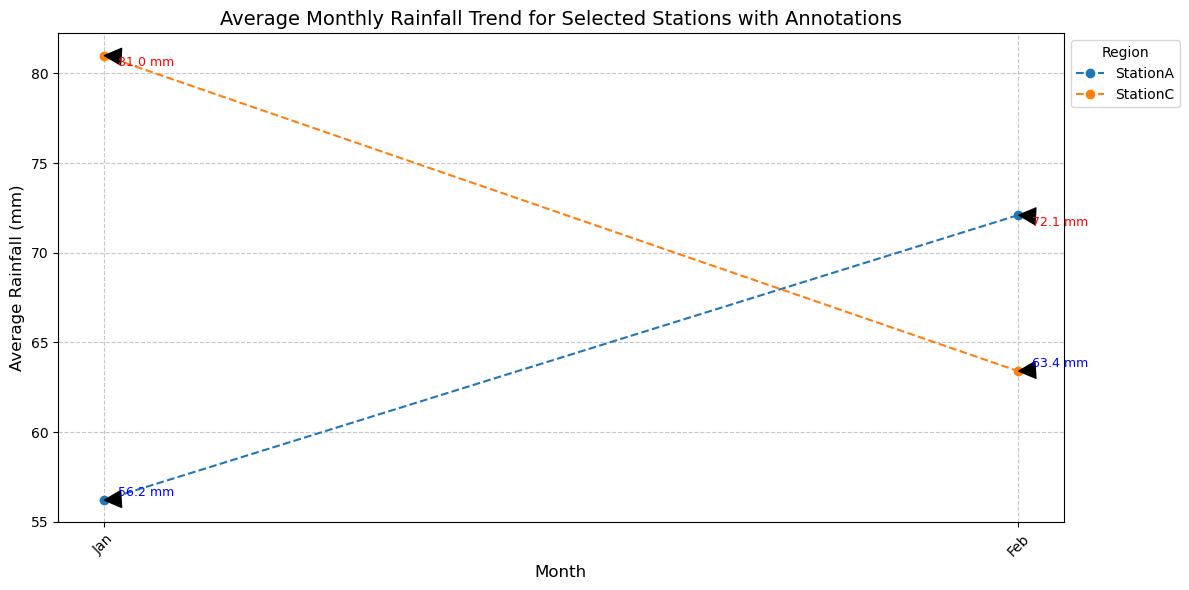

In [165]:
#Write your code here
fig7, ax7 = plt.subplots(figsize=(12, 6))
for station in selected_stations:
    if station in rainfall_trend.columns:
        ax7.plot(rainfall_trend.index, rainfall_trend[station], label=station, marker='o', linestyle='--')

        # Find and annotate max rainfall for this station
        max_rainfall_month = rainfall_trend[station].idxmax()
        max_rainfall_value = rainfall_trend[station].max()
        ax7.annotate(f'{max_rainfall_value:.1f} mm', xy=(max_rainfall_month, max_rainfall_value),
                        xytext=(10, -10), textcoords='offset points',
                        arrowprops=dict(facecolor='black', shrink=0.05),
                        ha='left', va='bottom', fontsize=9, color='red')

        # Find and annotate min rainfall for this station
        min_rainfall_month = rainfall_trend[station].idxmin()
        min_rainfall_value = rainfall_trend[station].min()
        ax7.annotate(f'{min_rainfall_value:.1f} mm', xy=(min_rainfall_month, min_rainfall_value),
                        xytext=(10, 10), textcoords='offset points',
                        arrowprops=dict(facecolor='black', shrink=0.05),
                        ha='left', va='top', fontsize=9, color='blue')

ax7.set_title('Average Monthly Rainfall Trend for Selected Stations with Annotations', fontsize=14)
ax7.set_xlabel('Month', fontsize=12)
ax7.set_ylabel('Average Rainfall (mm)', fontsize=12)
ax7.grid(True, linestyle='--', alpha=0.7)
ax7.legend(title='Station', loc='upper left')
ax7.tick_params(axis='x', rotation=45)
ax7.legend(title='Region', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.savefig('rainfall_trend_line_plot_annotated.png')
plt.show()

2. Create a **facet/grid plot** comparing rainfall trends by region and Urban/Rural status. (5 Marks)


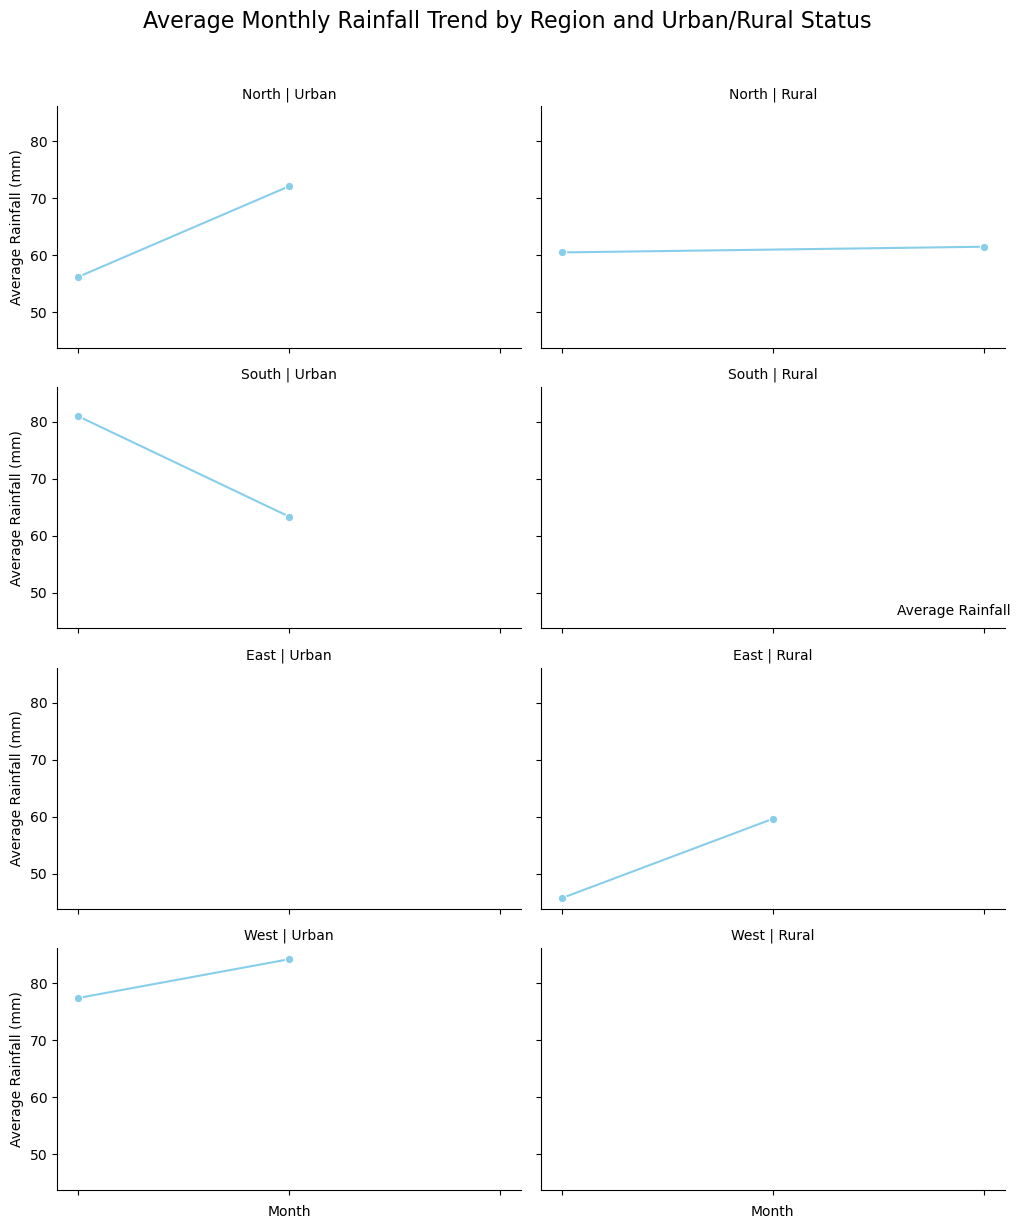

In [168]:
#Write your code here

# Ensure Month is ordered correctly
months_present = [m for m in months if m in rain_df['Month'].unique()]
rain_df['Month'] = pd.Categorical(rain_df['Month'], categories=months_present, ordered=True)

# Create FacetGrid
g = sns.FacetGrid(rain_df, row='Region', col='UrbanRural', height=3, aspect=1.5, sharey=True)

# Plot mean rainfall line per group
g.map_dataframe(sns.lineplot, x='Month', y='Rainfall_mm', estimator='mean', 
                marker='o', linestyle='-', color='skyblue')

# Aesthetics
g.set_axis_labels("Month", "Average Rainfall (mm)")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_xticklabels(rotation=45)
g.add_legend(title='Average Rainfall')

# Title and save
plt.suptitle('Average Monthly Rainfall Trend by Region and Urban/Rural Status', 
             y=1.02, fontsize=16)

plt.tight_layout()
plt.savefig('rainfall_facet_grid_plot.png')
plt.show()

3. Write a brief summary (in a Markdown cell) of your main insights from the data and visualizations. (5 Marks)

#Write your summary here

Rainfall Distribution:
-Total rainfall varies significantly across regions and between urban and rural areas.
-Some regions consistently receive more rainfall than others, with rural areas often experiencing slightly higher totals.

Monthly Patterns:
-Certain months, particularly during mid- and end-year (e.g., October to December), tend to show higher average rainfall.
-The trend is consistent across multiple stations, highlighting seasonal effects like monsoons.

Station Comparisons:
-Stations such as StationA and StationC show distinct rainfall trends, with noticeable peaks and dips across the year.
-Maximum rainfall often occurs in specific months, unique to each station's geographical location.

Temperature Relationships:
-Scatter plots show a weak correlation between maximum temperature and rainfall, indicating that temperature alone is not a strong predictor of rainfall.

Regional Climate Characteristics:
-Boxplots and heatmaps reveal that some regions (e.g., East or South) have wider rainfall variability and more extreme outliers.
-The average temperature range (MaxTemp - MinTemp) also varies by region, reflecting differences in local climate dynamics.




